In [1]:
import ast
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tldextract
from matplotlib.ticker import FuncFormatter
from tqdm.notebook import tqdm

tqdm.pandas()

In [2]:
%%time
df = pd.read_csv("notes_with_extracted_urls.csv")

<timed exec>:1: DtypeWarning: Columns (5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.


CPU times: user 27.7 s, sys: 4.03 s, total: 31.8 s
Wall time: 31.9 s


In [3]:
rows, cols = df.shape
print(f"{rows:,} rows × {cols:,} columns")

1,855,148 rows × 24 columns


In [4]:
df.columns

Index(['noteId', 'noteAuthorParticipantId', 'createdAtMillis', 'tweetId',
       'classification', 'believable', 'harmful', 'validationDifficulty',
       'misleadingOther', 'misleadingFactualError',
       'misleadingManipulatedMedia', 'misleadingOutdatedInformation',
       'misleadingMissingImportantContext', 'misleadingUnverifiedClaimAsFact',
       'misleadingSatire', 'notMisleadingOther',
       'notMisleadingFactuallyCorrect',
       'notMisleadingOutdatedButNotWhenWritten', 'notMisleadingClearlySatire',
       'notMisleadingPersonalOpinion', 'trustworthySources', 'summary',
       'isMediaNote', 'summary_urls'],
      dtype='object')

In [5]:
# find array lens of summary urls
df["num_urls"] = df["summary_urls"].progress_apply(
    lambda x: len(ast.literal_eval(x)) if pd.notnull(x) else 0
)

  0%|          | 0/1855148 [00:00<?, ?it/s]

### how many community notes don't have any URL

In [6]:
num_zero_url_rows = (df["num_urls"] == 0).sum()
print(f"Number of rows with 0 URLs: {num_zero_url_rows}")

Number of rows with 0 URLs: 327410


In [7]:
non_zero_percent = (df["num_urls"] != 0).mean() * 100
print(f"Percentage of rows with non-zero URLs: {non_zero_percent:.2f}%")

Percentage of rows with non-zero URLs: 82.35%


### how many notes have 2 or more URLs

In [8]:
url_df = df[df["num_urls"] != 0]
len(url_df)

1527738

In [9]:
num_more_than_two = (url_df["num_urls"] >= 2).sum()
print(f"Number of rows in url_df with num_urls >= 2: {num_more_than_two}")

percent_ge_2 = (url_df["num_urls"] >= 2).mean() * 100
print(f"Percentage of rows in url_df with num_urls >= 2: {percent_ge_2:.2f}%")

Number of rows in url_df with num_urls >= 2: 470714
Percentage of rows in url_df with num_urls >= 2: 30.81%


### extract domains from all URLs

In [10]:
def extract_domain(url):
    if not isinstance(url, str) or url.strip() == "":
        return ""
    extracted = tldextract.extract(url)
    if extracted.domain and extracted.suffix:
        return f"{extracted.domain}.{extracted.suffix}".lower()
    else:
        return ""

In [11]:
def extract_domains_from_row(url_list_str):
    try:
        urls = ast.literal_eval(url_list_str)
        return [extract_domain(url) for url in urls if isinstance(url, str)]
    except (ValueError, SyntaxError):
        return []

In [12]:
%%time
url_df["summary_domains"] = url_df["summary_urls"].progress_apply(
    extract_domains_from_row
)

  0%|          | 0/1527738 [00:00<?, ?it/s]

CPU times: user 1min 44s, sys: 795 ms, total: 1min 45s
Wall time: 1min 44s


<timed exec>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [13]:
url_df["num_domains"] = url_df["summary_domains"].progress_apply(len)

  0%|          | 0/1527738 [00:00<?, ?it/s]

/tmp/ipykernel_116020/3170967528.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  url_df["num_domains"] = url_df["summary_domains"].progress_apply(len)


In [14]:
url_df[["summary_urls", "summary_domains", "num_domains"]].head(10)

,summary_urls,summary_domains,num_domains
0,['https://sourcenm.com/2024/04/22/u-s-house-vo...,[sourcenm.com],1
1,['https://data.census.gov/all/profiles?q=All%2...,[census.gov],1
2,['https://www.reuters.com/world/us/senators-ho...,[reuters.com],1
3,['https://www.aol.com/finance/d-c-federal-cour...,[aol.com],1
4,['https://www.forbes.com/sites/rachelsandler/2...,"[forbes.com, washingtonpost.com]",2
6,['https://cleanvehiclerebate.org/en/faqs/can-i...,[cleanvehiclerebate.org],1
7,['https://www.nytimes.com/2021/01/10/us/trump-...,"[nytimes.com, wsj.com, nytimes.com]",3
8,['https://www.cnn.com/2022/06/10/media/ratings...,[cnn.com],1
9,['https://www.nytimes.com/2022/08/13/nyregion/...,"[nytimes.com, washingtonpost.com]",2
11,['https://www.npr.org/2021/03/27/981803154/why...,"[npr.org, statista.com]",2


In [15]:
url_df["url_domain_match"] = url_df["num_urls"] == url_df["num_domains"]

num_matches = url_df["url_domain_match"].sum()
print(f"Number of rows where num_urls == num_domains: {num_matches}")
print(url_df.shape)

Number of rows where num_urls == num_domains: 1527738
(1527738, 28)


/tmp/ipykernel_116020/1676849385.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  url_df["url_domain_match"] = url_df["num_urls"] == url_df["num_domains"]


In [16]:
mismatched_rows = url_df[url_df["url_domain_match"] == False]
print(
    mismatched_rows[
        ["summary_urls", "summary_domains", "num_urls", "num_domains"]
    ].head()
)

Empty DataFrame
Columns: [summary_urls, summary_domains, num_urls, num_domains]
Index: []


### distribution of the domains

In [17]:
all_domains = [domain for domains in url_df["summary_domains"] for domain in domains]
# Count frequency
domain_counts = Counter(all_domains)
print(len(domain_counts))

107104


In [18]:
domain_df = pd.DataFrame(
    domain_counts.items(), columns=["domain", "count"]
).sort_values(by="count", ascending=False)

In [19]:
total = domain_df["count"].sum()
domain_df["percentage"] = (domain_df["count"] / total) * 100
domain_df["percentage"] = domain_df["percentage"].round(3)

In [20]:
print(f"Total number of URLs in the data {int(total):,}")

Total number of URLs in the data 2,507,377


In [21]:
domain_df.head()

,domain,count,percentage
25,x.com,312160,12.450
13,wikipedia.org,153476,6.121
34,twitter.com,116977,4.665
9391,web3antivirus.io,50102,1.998
35,youtu.be,33737,1.346


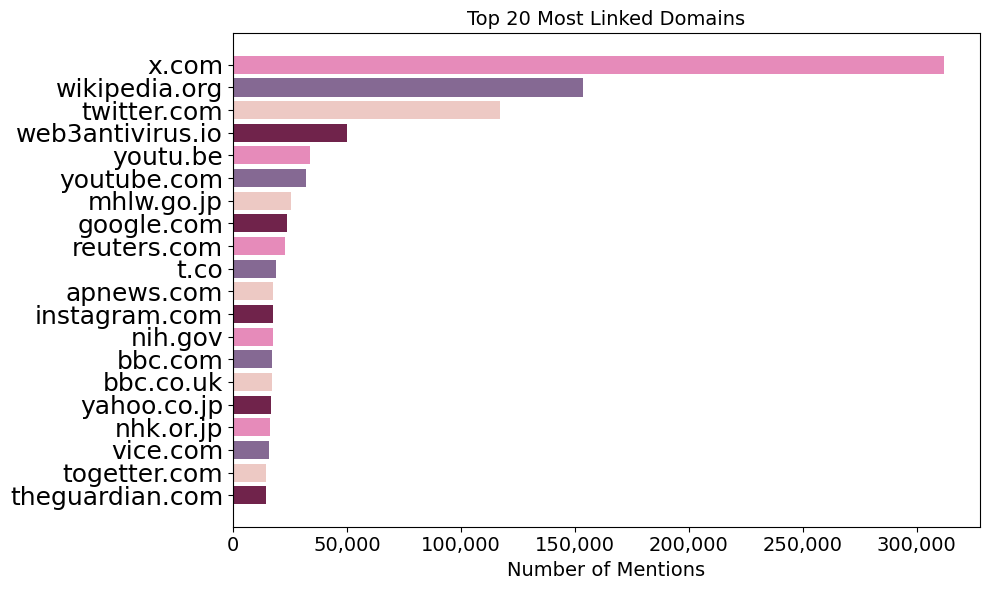

In [22]:
top_20 = domain_df.head(20).set_index("domain")["count"]

# Define colors
colors = ["#E68BBA", "#856993", "#EDC9C4", "#70234B"]
bar_colors = [colors[i % len(colors)] for i in range(len(top_20))]

plt.figure(figsize=(10, 6))
plt.barh(top_20.index, top_20.values, color=bar_colors)
plt.xlabel("Number of Mentions", fontsize=14)
plt.title("Top 20 Most Linked Domains", fontsize=14)
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.yticks(fontsize=18)
plt.xticks(fontsize=14)
plt.tight_layout()
plt.savefig("top_domains_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### distribution of the IFCN domains

In [23]:
ifcn_list = [
    "20minutes.fr",
    "abs-cbn.com",
    "afp.com",
    "ap.org",
    "apa.at",
    "hibrid.info",
    "africacheck.org",
    "sciencepresse.qc.ca",
    "animalpolitico.com",
    "annielab.org",
    "aosfatos.org",
    "aap.com.au",
    "boomlive.in",
    "br.de",
    "beamreports.com",
    "investigatebel.org",
    "correctiv.org",
    "thecable.ng",
    "cazadoresdefakenews.info",
    "liputan6.com",
    "checkyourfact.com",
    "chequeado.com",
    "civilnet.am",
    "colombiacheck.com",
    "cotejo.info",
    "demagog.org.pl",
    "demagog.cz",
    "demagog.sk",
    "dw.com",
    "dfrac.org",
    "digiteye.in",
    "doblecheck.cr",
    "dogrula.org",
    "dogrulukpayi.com",
    "efe.com",
    "ecuadorchequea.com",
    "ellinikahoaxes.gr",
    "factly.in",
    "factcheckcyprus.org",
    "factcheckzw.org",
    "fip.am",
    "factcheck.ge",
    "factcheck.org",
    "factcheckni.org",
    "factcrescendo.com",
    "factreview.gr",
    "fact-watch.org",
    "facta.news",
    "factchecklab.org",
    "factcheck.bg",
    "factcheck.kz",
    "factchequeado.com",
    "fakenews.rs",
    "faktyoxla.info",
    "faktisk.no",
    "faktograf.hr",
    "faktoje.al",
    "fastcheck.cl",
    "theferret.scot",
    "firstcheck.in",
    "france24.com",
    "fullfact.org",
    "fakenews.pl",
    "factual.ro",
    "gwaramedia.com",
    "sapo.pt",
    "hkbu.edu.hk",
    "kallxo.com",
    "indiatoday.in",
    "istinomer.rs",
    "istinomjer.ba",
    "jtbc.co.kr",
    "knack.be",
    "lasillavacia.com",
    "lakmusz.hu",
    "leadstories.com",
    "lessurligneurs.eu",
    "localvoicesliberia.com",
    "lupa.news",
    "mafindo.or.id",
    "maharat-news.com",
    "malaespinacheck.cl",
    "maldita.es",
    "manoramaonline.com",
    "poynter.org",
    "medicaldialogues.in",
    "medizin-transparent.at",
    "vistinomer.mk",
    "mindanews.com",
    "mygopen.com",
    "mythdetector.com",
    "nepalfactcheck.org",
    "mfcc.mn",
    "newsmobile.in",
    "newschecker.in",
    "newsmeter.in",
    "newtral.es",
    "observador.pt",
    "agenciaocote.com",
    "open.online",
    "ostro.si",
    "pa.media",
    "kompas.com",
    "pagellapolitica.it",
    "kashif.ps",
    "15min.lt",
    "pesacheck.org",
    "africauncensored.net",
    "politifact.com",
    "pravda.org.pl",
    "dubawa.org",
    "ptinews.com",
    "pressone.ph",
    "provereno.media",
    "rmit.edu.au",
    "rappler.com",
    "raskrikavanje.rs",
    "raskrinkavanje.ba",
    "raskrinkavanje.me",
    "rebaltica.lv",
    "reutersagency.com",
    "feedback.org",
    "stopfake.org",
    "stopfals.md",
    "suara.com",
    "telemundo.com",
    "thip.media",
    "togocheck.com",
    "thelallantop.com",
    "tfc-taiwan.org.tw",
    "telugupost.com",
    "tempo.co",
    "teyit.org",
    "thecanadianpressnews.ca",
    "thedispatch.com",
    "thejournal.ie",
    "thequint.com",
    "tsmliberia.com",
    "washingtonpost.com",
    "globes.co.il",
    "tirto.id",
    "tjekdet.dk",
    "uol.com.br",
    "usatoday.com",
    "vrtnws.be",
    "verafiles.org",
    "larepublica.pe",
    "verificat.cat",
    "verify-sy.com",
    "viralcheck.pt",
    "vishvasnews.com",
    "voxukraine.org",
    "wisconsinwatch.org",
    "wojownicyklawiatury.pl",
    "youturn.in",
    "dpa-factchecking.com",
    "francetvinfo.fr",
]
len(ifcn_list)

157

In [24]:
ifcn_df = domain_df[domain_df["domain"].isin(ifcn_list)].copy()
ifcn_df = ifcn_df.sort_values(by="count", ascending=False)

In [25]:
ifcn_df

,domain,count,percentage
17,usatoday.com,8386,0.334
5,washingtonpost.com,7566,0.302
647,uol.com.br,6753,0.269
140,politifact.com,6389,0.255
145,factcheck.org,4813,0.192
...,...,...,...
97706,factcheckcyprus.org,1,0.000
95368,factcheck.kz,1,0.000
93855,beamreports.com,1,0.000
40965,ostro.si,1,0.000


In [26]:
total_ifcn_percentage = ifcn_df["percentage"].sum()
print(f"Total IFCN domain percentage: {total_ifcn_percentage:.2f}%")

Total IFCN domain percentage: 2.85%


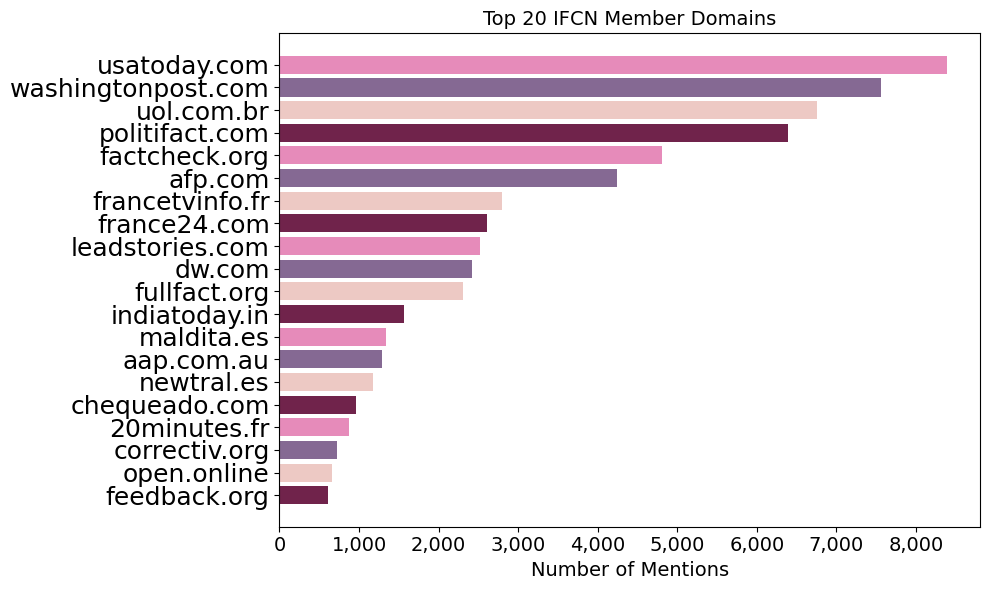

In [27]:
top_20_ifcn = ifcn_df.head(20)

colors = ["#E68BBA", "#856993", "#EDC9C4", "#70234B"]
bar_colors = [colors[i % len(colors)] for i in range(len(top_20_ifcn))]

plt.figure(figsize=(10, 6))
plt.barh(top_20_ifcn["domain"], top_20_ifcn["count"], color=bar_colors)

plt.xlabel("Number of Mentions", fontsize=14)
plt.title("Top 20 IFCN Member Domains", fontsize=14)
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.yticks(fontsize=18)
plt.xticks(fontsize=14)
plt.tight_layout()
plt.savefig("top_20_ifcn_domains_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### distribution of the Indian IFCN domains

In [28]:
ifcn_india = [
    "boomlive.in/fact-check",
    "dfrac.org",
    "digiteye.in",
    "factly.in",
    "factcrescendo.com",
    "firstcheck.in",
    "indiatoday.in/fact-check",
    "manoramaonline.com/fact-check",
    "medicaldialogues.in/fact-check",
    "newsmobile.in/nm-fact-checker",
    "newschecker.in",
    "newsmeter.in/fact-check",
    "newsmeter.in/factcheck-telugu",
    "newsmeter.in/fact-check-tamil",
    "newsmeter.in/fact-check-kannada",
    "newsmeter.in/fact-check-malayalam",
    "newsmeter.in/fact-check-health",
    "newsmeter.in/ai-deepfake",
    "newsmeter.in/whats-next",
    "ptinews.com/fact-detail",
    "thip.media/health-news-fact-check",
    "thelallantop.com/factcheck",
    "telugupost.com",
    "thequint.com/news/webqoof",
    "vishvasnews.com",
    "youturn.in/factcheck/",
]
len(ifcn_india)

26

In [29]:
def check_for_ifcn_india_urls(url_list_str, ifcn_india_paths):
    """
    Check if any URL in the list contains any of the IFCN India paths.
    Returns list of matched URLs and list of matched paths.
    """
    try:
        urls = ast.literal_eval(url_list_str) if pd.notnull(url_list_str) else []

        matched_urls = []
        matched_paths = []

        for url in urls:
            if not isinstance(url, str):
                continue

            for path in ifcn_india_paths:
                if path in url:
                    matched_urls.append(url)
                    matched_paths.append(path)

        return matched_urls, matched_paths
    except (ValueError, SyntaxError):
        return [], []

In [30]:
# Create new columns to store matched URLs and paths
url_df["ifcn_india_matched_urls"] = None
url_df["ifcn_india_matched_paths"] = None

/tmp/ipykernel_116020/1969071290.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  url_df["ifcn_india_matched_urls"] = None
/tmp/ipykernel_116020/1969071290.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  url_df["ifcn_india_matched_paths"] = None


In [31]:
results = url_df["summary_urls"].progress_apply(
    lambda x: check_for_ifcn_india_urls(x, ifcn_india)
)

  0%|          | 0/1527738 [00:00<?, ?it/s]

In [32]:
url_df["ifcn_india_matched_urls"] = results.apply(lambda x: x[0])
url_df["ifcn_india_matched_paths"] = results.apply(lambda x: x[1])

/tmp/ipykernel_116020/988302432.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  url_df["ifcn_india_matched_urls"] = results.apply(lambda x: x[0])
/tmp/ipykernel_116020/988302432.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  url_df["ifcn_india_matched_paths"] = results.apply(lambda x: x[1])


In [33]:
url_df["num_ifcn_india_matches"] = url_df["ifcn_india_matched_urls"].apply(len)

/tmp/ipykernel_116020/2160887142.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  url_df["num_ifcn_india_matches"] = url_df["ifcn_india_matched_urls"].apply(len)


In [34]:
total_matches = url_df["num_ifcn_india_matches"].sum()
print(f"Total matches to IFCN India paths: {total_matches}")

Total matches to IFCN India paths: 2003


In [35]:
all_matched_paths = [
    path for paths in url_df["ifcn_india_matched_paths"] for path in paths
]
path_counts = Counter(all_matched_paths)

path_df = pd.DataFrame(path_counts.items(), columns=["path", "count"]).sort_values(
    by="count", ascending=False
)

In [36]:
total_urls = domain_df["count"].sum()

# Add a new percentage column to path_df
path_df["percentage"] = (path_df["count"] / total_urls) * 100

In [37]:
path_df

,path,count,percentage
11,factly.in,328,0.013081
6,boomlive.in/fact-check,298,0.011885
9,indiatoday.in/fact-check,280,0.011167
5,newschecker.in,244,0.009731
8,thequint.com/news/webqoof,230,0.009173
0,factcrescendo.com,200,0.007976
4,dfrac.org,167,0.006660
1,newsmeter.in/fact-check,101,0.004028
2,youturn.in/factcheck/,49,0.001954
13,vishvasnews.com,30,0.001196


In [38]:
len(path_df)

20

In [39]:
total_count = path_df["count"].sum()
total_percentage = path_df["percentage"].sum()

print(f"Total Count: {total_count}")
print(f"Total Percentage: {total_percentage:.2f}%")

Total Count: 2003
Total Percentage: 0.08%


In [40]:
# filtered_df = url_df[url_df["num_ifcn_india_matches"] > 0].copy()
# result_df = filtered_df[["summary", "summary_urls", "summary_domains",
#                          "ifcn_india_matched_urls", "ifcn_india_matched_paths"]]

# result_df.to_csv("ifcn_india_matches.csv", index=False)

In [41]:
md_table = path_df[["path", "count"]].to_markdown(index=False)
md_table

'| path                              |   count |\n|:----------------------------------|--------:|\n| factly.in                         |     328 |\n| boomlive.in/fact-check            |     298 |\n| indiatoday.in/fact-check          |     280 |\n| newschecker.in                    |     244 |\n| thequint.com/news/webqoof         |     230 |\n| factcrescendo.com                 |     200 |\n| dfrac.org                         |     167 |\n| newsmeter.in/fact-check           |     101 |\n| youturn.in/factcheck/             |      49 |\n| vishvasnews.com                   |      30 |\n| thip.media/health-news-fact-check |      25 |\n| ptinews.com/fact-detail           |      21 |\n| telugupost.com                    |      10 |\n| newsmobile.in/nm-fact-checker     |       9 |\n| firstcheck.in                     |       3 |\n| digiteye.in                       |       2 |\n| thelallantop.com/factcheck        |       2 |\n| manoramaonline.com/fact-check     |       2 |\n| newsmeter.in/ai-d

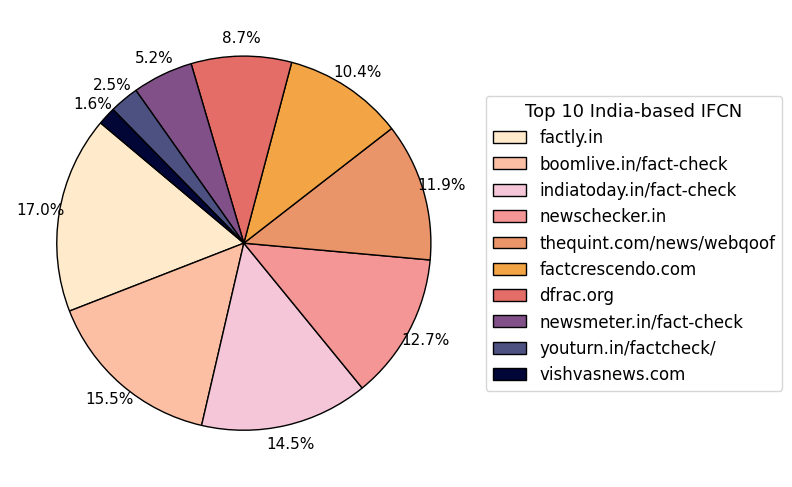

In [42]:
# Custom colors
custom_colors = [
    "#ffebcb",
    "#fcbfa4",
    "#f4c6d7",
    "#f39695",
    "#e99469",
    "#f3a444",
    "#e56d67",
    "#815089",
    "#4d5182",
    "#020637",
]

# Sort and select top 10 domains by count
top_10_paths = path_df.sort_values(by="count", ascending=False).head(10)
sorted_colors = custom_colors[: len(top_10_paths)]

# Pie chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts = ax.pie(
    top_10_paths["count"].values,
    labels=None,
    colors=sorted_colors,
    startangle=140,
    wedgeprops=dict(edgecolor="black"),
)

# Add % labels outside
total = top_10_paths["count"].sum()
for i, p in enumerate(wedges):
    angle = (p.theta2 - p.theta1) / 2.0 + p.theta1
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))

    percentage = top_10_paths["count"].values[i] / total * 100
    ax.annotate(
        f"{percentage:.1f}%",
        xy=(x, y),
        xytext=(1.1 * x, 1.1 * y),
        ha="center",
        va="center",
        fontsize=11,
    )

# Add legend
ax.legend(
    top_10_paths["path"],
    title="Top 10 India-based IFCN",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=12,
    title_fontsize=13,
)

plt.tight_layout()
plt.savefig("top_10_ifcn_india_paths_pie.png", dpi=300, bbox_inches="tight")
plt.show()

In [43]:
# 1. Find IFCN India URLs that don't start with https, http, or www
def check_url_format(urls):
    """Check if URLs start with http, https, or www"""
    if not urls or len(urls) == 0:
        return []

    non_standard_urls = []
    for url in urls:
        # Check if URL doesn't start with http, https, or www
        if not (
            url.startswith("http://")
            or url.startswith("https://")
            or url.startswith("www.")
        ):
            non_standard_urls.append(url)

    return non_standard_urls


# Apply to all matched URLs
url_df["non_standard_ifcn_urls"] = url_df["ifcn_india_matched_urls"].apply(
    check_url_format
)
url_df["num_non_standard_ifcn_urls"] = url_df["non_standard_ifcn_urls"].apply(len)

# Get all non-standard URLs
all_non_standard_urls = [
    url for urls in url_df["non_standard_ifcn_urls"] for url in urls if urls
]

# Count of non-standard URLs
num_non_standard_urls = len(all_non_standard_urls)
print(
    f"Number of IFCN India URLs that don't start with https, http, or www: {num_non_standard_urls}"
)

/tmp/ipykernel_116020/1733035642.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  url_df["non_standard_ifcn_urls"] = url_df["ifcn_india_matched_urls"].apply(
/tmp/ipykernel_116020/1733035642.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  url_df["num_non_standard_ifcn_urls"] = url_df["non_standard_ifcn_urls"].apply(len)


Number of IFCN India URLs that don't start with https, http, or www: 6


In [44]:
if num_non_standard_urls > 0:
    print("\nNon-standard URLs found:")
    for url in sorted(set(all_non_standard_urls)):
        print(f"- {url}")


Non-standard URLs found:
- Rajasthan.https://newsmeter.in/fact-check/train-collision-near-rajasthans-lalgarh-railway-station-no-it-was-a-mock-drill-739066
- factly.in
- factly.in/the-person-dancing-with-a-foreign-lady-in-the-photo-is-not-mahatma-gandhi-but-an-australian-artist/
- factly.in/yamuna-aarti-was-not-performed-for-the-first-time-in-february-2025-it-was-first-held-in-november-2015/#:~:text=The%20Delhi%20government%20held%20the,here%20every%20Sunday%20and%20Tuesday
- indiatoday.in/fact-check/story/fact-check-yamuna-aarti-delhi-bjp-victory-assembly-polls-2025-2679568-2025-02-13
- youturn.in/factcheck/peri…


In [45]:
# 2. Count notes with at least 1 India URL
notes_with_india_urls = sum(url_df["num_ifcn_india_matches"] > 0)
print(f"\nNumber of notes with at least 1 India IFCN URL: {notes_with_india_urls}")

# Calculate percentage of all notes
total_notes = len(url_df)
percentage = (notes_with_india_urls / total_notes) * 100
print(f"Percentage of notes with India IFCN URLs: {percentage:.2f}%")


Number of notes with at least 1 India IFCN URL: 1873
Percentage of notes with India IFCN URLs: 0.12%
